# Reefer Power Forecasting Workbook

Single working notebook for phased implementation. Phase 1 covers data inventory, aggregation, weather alignment, EDA, and a reproducible baseline. Later phases are added as new headings in the same notebook.

In [1]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

ROOT = Path.cwd()
TARGET_PATH = ROOT / 'target_timestamps.csv'
REEFER_PATH = ROOT / 'reefer_release.csv'
WEATHER_DIR = ROOT / 'Wetterdaten Okt 25 - 23 Feb 26'
SUBMISSION_TEMPLATE_PATH = ROOT / 'templates' / 'submission_template.csv'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'Root: {ROOT}')
print(f'Reefer file exists: {REEFER_PATH.exists()}')
print(f'Weather dir exists: {WEATHER_DIR.exists()}')
print(f'Target file exists: {TARGET_PATH.exists()}')

Root: /Users/ashutoshchatterjee/Documents/Projects/eurogate
Reefer file exists: True
Weather dir exists: True
Target file exists: True


In [2]:
def inventory_workspace(root: Path, max_depth: int = 2) -> pd.DataFrame:
    rows = []
    for path in sorted(root.rglob('*')):
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue
        rows.append(
            {
                'path': str(path.relative_to(root)),
                'kind': 'dir' if path.is_dir() else 'file',
                'size_mb': round(path.stat().st_size / 1_000_000, 2) if path.is_file() else np.nan,
            }
        )
    return pd.DataFrame(rows)


workspace_inventory = inventory_workspace(ROOT, max_depth=2)
workspace_inventory

,path,kind,size_mb
0,.DS_Store,file,0.01
1,.git,dir,NaN
2,.git/FETCH_HEAD,file,0.00
3,.git/HEAD,file,0.00
4,.git/config,file,0.00
5,.git/description,file,0.00
6,.git/hooks,dir,NaN
7,.git/info,dir,NaN
8,.git/logs,dir,NaN
9,.git/objects,dir,NaN


In [3]:
targets = pd.read_csv(TARGET_PATH, parse_dates=['timestamp_utc'])
targets['timestamp_utc'] = pd.to_datetime(targets['timestamp_utc'], utc=True)

print(f'Target rows: {len(targets)}')
print(f'Target range: {targets["timestamp_utc"].min()} -> {targets["timestamp_utc"].max()}')
print(f'Unique target days: {targets["timestamp_utc"].dt.date.nunique()}')
targets.head()

Target rows: 223
Target range: 2026-01-01 00:00:00+00:00 -> 2026-01-10 06:00:00+00:00
Unique target days: 10


,timestamp_utc
0,2026-01-01 00:00:00+00:00
1,2026-01-01 01:00:00+00:00
2,2026-01-01 02:00:00+00:00
3,2026-01-01 03:00:00+00:00
4,2026-01-01 04:00:00+00:00


In [4]:
reefer_sample = pd.read_csv(REEFER_PATH, sep=';', nrows=5)
weather_samples = {
    path.name: pd.read_csv(path, sep=';', nrows=5)
    for path in sorted(WEATHER_DIR.glob('*.csv'))
}

print('Reefer columns:')
print(list(reefer_sample.columns))
display(reefer_sample)

for name, sample in weather_samples.items():
    print(f'\n{name}')
    display(sample.head(3))

Reefer columns:
['container_visit_uuid', 'customer_uuid', 'container_uuid', 'HardwareType', 'EventTime', 'AvPowerCons', 'TtlEnergyConsHour', 'TtlEnergyCons', 'TemperatureSetPoint', 'TemperatureAmbient', 'TemperatureReturn', 'RemperatureSupply', 'ContainerSize', 'stack_tier']


,container_visit_uuid,customer_uuid,container_uuid,HardwareType,EventTime,AvPowerCons,TtlEnergyConsHour,TtlEnergyCons,TemperatureSetPoint,TemperatureAmbient,TemperatureReturn,RemperatureSupply,ContainerSize,stack_tier
0,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 00:00:00.000,"887,79348807004","887,437325740224","1519376,48069997",-18,"9,625","-18,1","-19,95",40,1
1,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 01:00:00.000,"928,909479307594","928,094826894834","1520304,57552687",-18,"10,0666666666667",-18,"-19,9",40,1
2,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 02:00:00.000,"929,646455537803","929,299938133079","1521233,875465",-18,"10,25","-17,975","-19,85",40,1
3,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 03:00:00.000,"923,307626629993","925,736719068447","1522159,61218407",-18,"10,55","-17,9","-19,8",40,1
4,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 04:00:00.000,"945,029191896214","944,842351244323","1523104,45453532",-18,"11,0666666666667","-17,8333333333333","-19,7666666666667",40,1



CTH_Temperatur_VC_Halle3 Okt 25 - 23 Feb 26.csv


,ConfigID,UtcTimestamp,TimeResolution,Quality,Value
0,39048,2025-09-24 10:00:50.943,40,192,"13,2"
1,39048,2025-10-10 09:56:28.230,40,192,"14,4"
2,39048,2025-10-10 09:56:37.237,30,192,"14,5"



CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26.csv


...

,ConfigID,UtcTimestamp,TimeResolution,Quality,Value
0,39089,2025-09-24 10:00:50.943,40.0,192,"6,9"
1,39089,2025-10-10 09:49:34.283,NaN,192,"5,7"
2,39089,2025-10-10 09:49:37.280,10.0,192,"5,8"



CTH_Windrichtung_VC_Halle3  Okt 25 - 23 Feb 26.csv


,ConfigID,UtcTimestamp,TimeResolution,Quality,Value
0,39051,2025-11-01 00:00:01.853,20.0,192,"154,5"
1,39051,2025-11-01 00:00:04.850,NaN,192,"173,8"
2,39051,2025-11-01 00:00:07.857,10.0,192,"178,4"



CTH_Windrichtung_Zentralgate  Okt 25 - 23 Feb 26.csv


,ConfigID,UtcTimestamp,TimeResolution,Quality,Value
0,39091,2025-11-01 00:00:01.960,10.0,192,"174,3"
1,39091,2025-11-01 00:00:04.960,NaN,192,"164,4"
2,39091,2025-11-01 00:00:07.957,10.0,192,"159,9"


In [5]:
def parse_decimal_series(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')
    return pd.to_numeric(series.astype(str).str.replace(',', '.', regex=False), errors='coerce')


def load_and_aggregate_reefer(path: Path, chunksize: int = 500_000) -> pd.DataFrame:
    usecols = [
        'container_visit_uuid',
        'container_uuid',
        'HardwareType',
        'EventTime',
        'AvPowerCons',
        'TemperatureSetPoint',
        'TemperatureAmbient',
        'TemperatureReturn',
        'RemperatureSupply',
        'ContainerSize',
    ]
    stats_by_hour: dict[pd.Timestamp, dict[str, float]] = defaultdict(
        lambda: {
            'total_power_kw': 0.0,
            'n_active_rows': 0.0,
            'sum_setpoint': 0.0,
            'sum_ambient': 0.0,
            'sum_return': 0.0,
            'sum_supply': 0.0,
        }
    )
    reefers_by_hour: dict[pd.Timestamp, set[str]] = defaultdict(set)
    containers_by_hour: dict[pd.Timestamp, set[str]] = defaultdict(set)

    reader = pd.read_csv(
        path,
        sep=';',
        usecols=usecols,
        parse_dates=['EventTime'],
        chunksize=chunksize,
        low_memory=False,
    )

    for idx, chunk in enumerate(reader, start=1):
        chunk = chunk.copy()
        chunk['AvPowerCons'] = parse_decimal_series(chunk['AvPowerCons'])
        chunk['TemperatureSetPoint'] = parse_decimal_series(chunk['TemperatureSetPoint'])
        chunk['TemperatureAmbient'] = parse_decimal_series(chunk['TemperatureAmbient'])
        chunk['TemperatureReturn'] = parse_decimal_series(chunk['TemperatureReturn'])
        chunk['RemperatureSupply'] = parse_decimal_series(chunk['RemperatureSupply'])
        chunk['power_kw'] = chunk['AvPowerCons'] / 1000.0

        for event_time, hour_df in chunk.groupby('EventTime', sort=True):
            stats = stats_by_hour[event_time]
            stats['total_power_kw'] += float(hour_df['power_kw'].sum())
            stats['n_active_rows'] += float(len(hour_df))
            stats['sum_setpoint'] += float(hour_df['TemperatureSetPoint'].fillna(0).sum())
            stats['sum_ambient'] += float(hour_df['TemperatureAmbient'].fillna(0).sum())
            stats['sum_return'] += float(hour_df['TemperatureReturn'].fillna(0).sum())
            stats['sum_supply'] += float(hour_df['RemperatureSupply'].fillna(0).sum())
            reefers_by_hour[event_time].update(hour_df['container_visit_uuid'].dropna().astype(str))
            containers_by_hour[event_time].update(hour_df['container_uuid'].dropna().astype(str))

        print(f'Processed chunk {idx}')

    rows = []
    for event_time in sorted(stats_by_hour):
        stats = stats_by_hour[event_time]
        row_count = int(stats['n_active_rows'])
        rows.append(
            {
                'EventTime': event_time,
                'total_power_kw': stats['total_power_kw'],
                'n_active_rows': row_count,
                'n_reefers': float(len(reefers_by_hour[event_time])),
                'n_container_ids': float(len(containers_by_hour[event_time])),
                'avg_setpoint': stats['sum_setpoint'] / row_count if row_count else np.nan,
                'avg_ambient_temp': stats['sum_ambient'] / row_count if row_count else np.nan,
                'avg_return_temp': stats['sum_return'] / row_count if row_count else np.nan,
                'avg_supply_temp': stats['sum_supply'] / row_count if row_count else np.nan,
            }
        )

    hourly_total = pd.DataFrame(rows).set_index('EventTime').sort_index()
    hourly_total.index.name = 'EventTime'
    return hourly_total


hourly_total = load_and_aggregate_reefer(REEFER_PATH)
hourly_total.head()

Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed chunk 7
Processed chunk 8


,total_power_kw,n_active_rows,n_reefers,n_container_ids,avg_setpoint,avg_ambient_temp,avg_return_temp,avg_supply_temp
EventTime,,,,,,,,
2025-01-01 00:00:00,843.247345,425,425.0,425.0,-0.727765,6.809843,-0.485510,-1.333882
2025-01-01 01:00:00,866.865919,425,425.0,425.0,-0.727765,7.376843,-0.579588,-1.367902
2025-01-01 02:00:00,865.292780,425,425.0,425.0,-0.727765,7.690537,-0.558302,-1.343631
2025-01-01 03:00:00,875.907910,425,425.0,425.0,-0.727765,7.835937,-0.560024,-1.390851
2025-01-01 04:00:00,873.150000,425,425.0,425.0,-0.727765,8.376204,-0.535957,-1.409565


In [6]:
print(f'Aggregated hours: {len(hourly_total)}')
print(f'Aggregated range: {hourly_total.index.min()} -> {hourly_total.index.max()}')
display(hourly_total.describe().T)

missing_hours = pd.date_range(hourly_total.index.min(), hourly_total.index.max(), freq='h').difference(hourly_total.index)
print(f'Missing hourly timestamps inside reefer range: {len(missing_hours)}')
missing_hours[:10]

Aggregated hours: 8403
Aggregated range: 2025-01-01 00:00:00 -> 2026-01-10 06:00:00


,count,mean,std,min,25%,50%,75%,max
total_power_kw,8403.0,1066.836561,280.189290,25.181238,857.536994,1037.777508,1233.877610,2111.213573
n_active_rows,8403.0,449.191598,93.142807,11.000000,382.000000,439.000000,502.000000,777.000000
n_reefers,8403.0,449.191598,93.142807,11.000000,382.000000,439.000000,502.000000,777.000000
n_container_ids,8403.0,449.189932,93.142985,11.000000,382.000000,439.000000,502.000000,777.000000
avg_setpoint,8403.0,-0.067648,2.248439,-7.752200,-1.525427,0.052278,1.347984,10.035577
avg_ambient_temp,8403.0,13.022772,7.419654,-3.470194,7.003520,13.358043,18.665734,37.406306
avg_return_temp,8403.0,0.293958,2.194902,-6.933563,-1.107408,0.370845,1.686891,10.264693
avg_supply_temp,8403.0,-0.763288,2.433602,-8.910633,-2.311886,-0.620990,0.811558,10.042379


Missing hourly timestamps inside reefer range: 580


DatetimeIndex(['2025-03-30 09:00:00', '2025-03-30 10:00:00', '2025-03-30 11:00:00', '2025-03-30 12:00:00', '2025-03-30 13:00:00', '2025-03-30 14:00:00',
               '2025-03-30 15:00:00', '2025-03-30 16:00:00', '2025-03-30 17:00:00', '2025-03-30 18:00:00'],
              dtype='datetime64[us]', freq='h')

In [7]:
def weather_column_name(path: Path) -> str:
    stem = path.stem
    stem = stem.replace(' Okt 25 - 23 Feb 26', '')
    cleaned = stem.lower()
    for old, new in [('cth_', ''), (' ', '_'), ('-', '_')]:
        cleaned = cleaned.replace(old, new)
    while '__' in cleaned:
        cleaned = cleaned.replace('__', '_')
    return cleaned.strip('_')


def load_weather_frame(weather_dir: Path) -> pd.DataFrame:
    hourly_frames = []
    for path in sorted(weather_dir.glob('*.csv')):
        column_name = weather_column_name(path)
        weather = pd.read_csv(path, sep=';', parse_dates=['UtcTimestamp'])
        weather['Value'] = parse_decimal_series(weather['Value'])
        weather['hour_utc'] = weather['UtcTimestamp'].dt.floor('h')
        hourly = weather.groupby('hour_utc')['Value'].mean().rename(column_name).to_frame()
        hourly_frames.append(hourly)
    return pd.concat(hourly_frames, axis=1, sort=True).sort_index()


weather_hourly = load_weather_frame(WEATHER_DIR)
print(f'Weather hourly range: {weather_hourly.index.min()} -> {weather_hourly.index.max()}')
display(weather_hourly.head())

Weather hourly range: 2025-09-24 10:00:00 -> 2026-02-23 14:00:00


,temperatur_vc_halle3,temperatur_zentralgate,wind_vc_halle3,wind_zentralgate,windrichtung_vc_halle3,windrichtung_zentralgate
hour_utc,,,,,,
2025-09-24 10:00:00,13.200000,13.200000,2.500000,6.900000,NaN,NaN
2025-10-10 09:00:00,14.440000,14.750000,3.414141,5.279474,NaN,NaN
2025-10-10 10:00:00,15.295192,15.535714,2.173228,5.321187,NaN,NaN
2025-10-10 11:00:00,15.012281,13.962500,2.728993,6.330967,NaN,NaN
2025-10-10 12:00:00,15.679630,15.720000,2.626178,6.199819,NaN,NaN


In [8]:
hourly_total = hourly_total.merge(weather_hourly, left_index=True, right_index=True, how='left')
hourly_total['hour'] = hourly_total.index.hour
hourly_total['day_of_week'] = hourly_total.index.dayofweek
hourly_total['date'] = hourly_total.index.date

weather_missing = hourly_total[weather_hourly.columns].isna().mean().sort_values(ascending=False)
display(weather_missing.to_frame('missing_share'))
hourly_total.head()

,missing_share
windrichtung_vc_halle3,0.804475
windrichtung_zentralgate,0.804475
temperatur_vc_halle3,0.747590
wind_vc_halle3,0.747590
temperatur_zentralgate,0.743306
wind_zentralgate,0.743306


,total_power_kw,n_active_rows,n_reefers,n_container_ids,avg_setpoint,avg_ambient_temp,avg_return_temp,avg_supply_temp,temperatur_vc_halle3,temperatur_zentralgate,wind_vc_halle3,wind_zentralgate,windrichtung_vc_halle3,windrichtung_zentralgate,hour,day_of_week,date
EventTime,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,843.247345,425,425.0,425.0,-0.727765,6.809843,-0.485510,-1.333882,NaN,NaN,NaN,NaN,NaN,NaN,0,2,2025-01-01
2025-01-01 01:00:00,866.865919,425,425.0,425.0,-0.727765,7.376843,-0.579588,-1.367902,NaN,NaN,NaN,NaN,NaN,NaN,1,2,2025-01-01
2025-01-01 02:00:00,865.292780,425,425.0,425.0,-0.727765,7.690537,-0.558302,-1.343631,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2025-01-01
2025-01-01 03:00:00,875.907910,425,425.0,425.0,-0.727765,7.835937,-0.560024,-1.390851,NaN,NaN,NaN,NaN,NaN,NaN,3,2,2025-01-01
2025-01-01 04:00:00,873.150000,425,425.0,425.0,-0.727765,8.376204,-0.535957,-1.409565,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2025-01-01


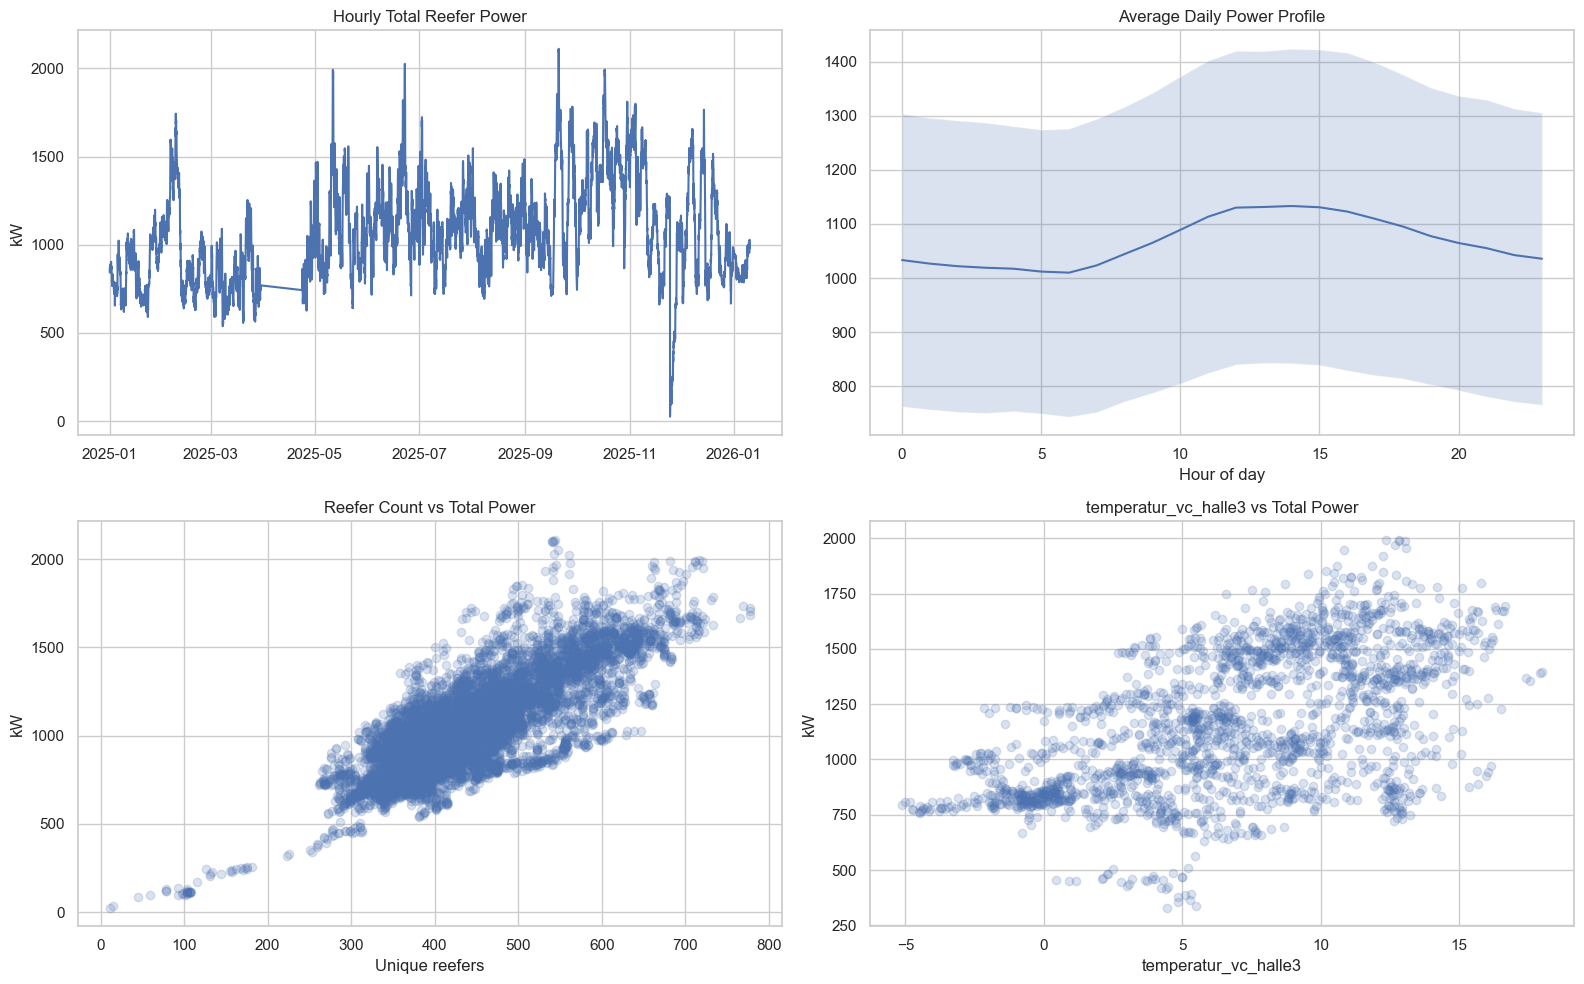

75th percentile high-load threshold: 1233.88 kW


,high_load_count_by_hour
EventTime,
0,72
1,69
2,65
3,67
4,65
5,63
6,68
7,72
8,80


In [9]:
hourly_profile = hourly_total.groupby('hour')['total_power_kw'].agg(['mean', 'std', 'min', 'max'])
high_load_threshold = hourly_total['total_power_kw'].quantile(0.75)
high_load_hours = hourly_total[hourly_total['total_power_kw'] >= high_load_threshold]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(hourly_total.index, hourly_total['total_power_kw'])
axes[0, 0].set_title('Hourly Total Reefer Power')
axes[0, 0].set_ylabel('kW')

axes[0, 1].plot(hourly_profile.index, hourly_profile['mean'])
axes[0, 1].fill_between(hourly_profile.index, hourly_profile['mean'] - hourly_profile['std'], hourly_profile['mean'] + hourly_profile['std'], alpha=0.2)
axes[0, 1].set_title('Average Daily Power Profile')
axes[0, 1].set_xlabel('Hour of day')

axes[1, 0].scatter(hourly_total['n_reefers'], hourly_total['total_power_kw'], alpha=0.2)
axes[1, 0].set_title('Reefer Count vs Total Power')
axes[1, 0].set_xlabel('Unique reefers')
axes[1, 0].set_ylabel('kW')

ambient_col = 'temperatur_vc_halle3' if 'temperatur_vc_halle3' in hourly_total.columns else 'avg_ambient_temp'
axes[1, 1].scatter(hourly_total[ambient_col], hourly_total['total_power_kw'], alpha=0.2)
axes[1, 1].set_title(f'{ambient_col} vs Total Power')
axes[1, 1].set_xlabel(ambient_col)
axes[1, 1].set_ylabel('kW')

plt.tight_layout()
plt.show()

print(f'75th percentile high-load threshold: {high_load_threshold:.2f} kW')
display(high_load_hours.groupby(high_load_hours.index.hour).size().rename('high_load_count_by_hour').to_frame())

In [10]:
def evaluate_model(actual: np.ndarray, predicted: np.ndarray, predicted_p90: np.ndarray, high_load_mask: np.ndarray | None = None) -> dict[str, float]:
    mae_all = np.mean(np.abs(actual - predicted))
    if high_load_mask is None:
        threshold = np.percentile(actual, 75)
        high_load_mask = actual >= threshold
    mae_peak = np.mean(np.abs(actual[high_load_mask] - predicted[high_load_mask]))

    error = actual - predicted_p90
    pinball_p90 = np.mean(np.where(error > 0, 0.9 * error, -0.1 * error))
    score = 0.5 * mae_all + 0.3 * mae_peak + 0.2 * pinball_p90
    return {
        'mae_all': float(mae_all),
        'mae_peak': float(mae_peak),
        'pinball_p90': float(pinball_p90),
        'combined_score': float(score),
    }


def predict_avg_naive(history: pd.DataFrame, target_hours: pd.DatetimeIndex) -> tuple[list[float], list[float]]:
    preds, p90s = [], []
    hourly_means = history.groupby(history.index.hour)['total_power_kw'].mean()
    fallback = history['total_power_kw'].mean()

    for ts in target_hours:
        values = []
        for lag in (24, 48, 168):
            ref = ts - pd.Timedelta(hours=lag)
            if ref in history.index:
                values.append(history.loc[ref, 'total_power_kw'])
        pred = float(np.mean(values)) if values else float(hourly_means.get(ts.hour, fallback))
        preds.append(pred)
        p90s.append(pred * 1.15)
    return preds, p90s


def walk_forward_evaluate(hourly_df: pd.DataFrame, predict_fn, n_days: int = 14) -> dict[str, float]:
    all_actuals, all_preds, all_p90s = [], [], []
    end_date = hourly_df.index.max().normalize()

    for day_offset in range(n_days, 0, -1):
        target_date = end_date - pd.Timedelta(days=day_offset)
        target_hours = pd.date_range(target_date, periods=24, freq='h')
        history = hourly_df[hourly_df.index < target_date]
        actuals_day = hourly_df.loc[hourly_df.index.isin(target_hours), 'total_power_kw']

        if len(history) == 0 or len(actuals_day) < 24:
            continue

        preds, p90s = predict_fn(history, target_hours)
        all_actuals.extend(actuals_day.to_numpy())
        all_preds.extend(preds)
        all_p90s.extend(p90s)

    return evaluate_model(np.asarray(all_actuals), np.asarray(all_preds), np.asarray(all_p90s))


baseline_metrics = walk_forward_evaluate(hourly_total[['total_power_kw']].copy(), predict_avg_naive, n_days=14)
baseline_metrics

{'mae_all': 79.62523716906675,
 'mae_peak': 87.66594333920882,
 'pinball_p90': 16.238236991779466,
 'combined_score': 69.36004898465191}

In [11]:
def format_submission(submission: pd.DataFrame) -> pd.DataFrame:
    out = submission.copy()
    out['timestamp_utc'] = pd.to_datetime(out['timestamp_utc'], utc=True).dt.strftime('%Y-%m-%dT%H:%M:%SZ')
    out['pred_power_kw'] = out['pred_power_kw'].round(2)
    out['pred_p90_kw'] = out['pred_p90_kw'].round(2)
    return out[['timestamp_utc', 'pred_power_kw', 'pred_p90_kw']]


def validate_submission(submission: pd.DataFrame, targets_df: pd.DataFrame) -> None:
    sub_ts = set(pd.to_datetime(submission['timestamp_utc'], utc=True))
    target_ts = set(pd.to_datetime(targets_df['timestamp_utc'], utc=True))

    assert sub_ts == target_ts, 'Submission timestamps must match target timestamps exactly.'
    assert submission.duplicated(subset='timestamp_utc').sum() == 0, 'Duplicate timestamps found.'
    assert submission['pred_power_kw'].notna().all(), 'pred_power_kw contains NaN.'
    assert submission['pred_p90_kw'].notna().all(), 'pred_p90_kw contains NaN.'
    assert (submission['pred_power_kw'] >= 0).all(), 'pred_power_kw contains negative values.'
    assert (submission['pred_p90_kw'] >= submission['pred_power_kw']).all(), 'pred_p90_kw must stay above pred_power_kw.'


target_hours = pd.to_datetime(targets['timestamp_utc'], utc=True)
history = hourly_total[['total_power_kw']].copy()
history.index = pd.to_datetime(history.index, utc=True)
preds, p90s = predict_avg_naive(history, pd.DatetimeIndex(target_hours))

phase_1_submission = pd.DataFrame(
    {
        'timestamp_utc': target_hours,
        'pred_power_kw': preds,
        'pred_p90_kw': p90s,
    }
)
phase_1_submission = format_submission(phase_1_submission)
validate_submission(phase_1_submission, targets)

phase_1_submission.to_csv(OUTPUT_DIR / 'phase_1_baseline_predictions.csv', index=False)
phase_1_submission.head()

,timestamp_utc,pred_power_kw,pred_p90_kw
0,2026-01-01T00:00:00Z,805.91,926.79
1,2026-01-01T01:00:00Z,799.38,919.29
2,2026-01-01T02:00:00Z,801.63,921.88
3,2026-01-01T03:00:00Z,800.39,920.45
4,2026-01-01T04:00:00Z,798.14,917.86


## Phase 2 - Core Model

Phase 2 adds a first supervised model using walk-forward-safe features built from aggregated hourly demand. The notebook prefers LightGBM when it imports successfully and otherwise falls back to scikit-learn's histogram gradient boosting so the pipeline still runs in the current environment.

In [12]:
from sklearn.ensemble import HistGradientBoostingRegressor

try:
    from lightgbm import LGBMRegressor
    MODEL_BACKEND = 'lightgbm'
except Exception as exc:
    LGBMRegressor = None
    MODEL_BACKEND = f'sklearn_hist_gbr ({exc.__class__.__name__})'

MODEL_BACKEND

'sklearn_hist_gbr (OSError)'

In [13]:
def build_phase_2_features(hourly_df: pd.DataFrame) -> pd.DataFrame:
    df = hourly_df.copy().sort_index()

    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['day_of_year'] = df.index.dayofyear
    iso_calendar = df.index.isocalendar()
    df['week_of_year'] = iso_calendar.week.astype(int)
    df['month'] = df.index.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    lag_columns = ['total_power_kw', 'n_reefers', 'avg_setpoint', 'avg_ambient_temp']
    for source_col in lag_columns:
        for lag in (24, 48, 72, 168, 336):
            df[f'{source_col}_lag_{lag}h'] = df[source_col].shift(lag)

    shifted_power = df['total_power_kw'].shift(24)
    df['power_rolling_mean_24h'] = shifted_power.rolling(24, min_periods=12).mean()
    df['power_rolling_std_24h'] = shifted_power.rolling(24, min_periods=12).std()
    df['power_rolling_max_24h'] = shifted_power.rolling(24, min_periods=12).max()
    df['power_rolling_mean_168h'] = shifted_power.rolling(168, min_periods=72).mean()
    df['power_rolling_std_168h'] = shifted_power.rolling(168, min_periods=72).std()

    df['power_delta_24_48'] = df['total_power_kw_lag_24h'] - df['total_power_kw_lag_48h']
    df['power_delta_24_168'] = df['total_power_kw_lag_24h'] - df['total_power_kw_lag_168h']
    df['reefer_delta_24_48'] = df['n_reefers_lag_24h'] - df['n_reefers_lag_48h']
    df['power_per_reefer_lag_24h'] = df['total_power_kw_lag_24h'] / df['n_reefers_lag_24h'].replace(0, np.nan)

    weather_feature_cols = [
        col for col in df.columns
        if col.startswith('temperatur_') or col.startswith('wind_') or col.startswith('windrichtung_')
    ]
    for col in weather_feature_cols:
        df[f'{col}_lag_24h'] = df[col].shift(24)

    if 'temperatur_vc_halle3' in df.columns and 'temperatur_zentralgate' in df.columns:
        df['temperature_spread'] = df['temperatur_vc_halle3'] - df['temperatur_zentralgate']

    return df


phase_2_features = build_phase_2_features(hourly_total)
phase_2_features[['total_power_kw', 'n_reefers']].head()

,total_power_kw,n_reefers
EventTime,,
2025-01-01 00:00:00,843.247345,425.0
2025-01-01 01:00:00,866.865919,425.0
2025-01-01 02:00:00,865.292780,425.0
2025-01-01 03:00:00,875.907910,425.0
2025-01-01 04:00:00,873.150000,425.0


In [14]:
feature_columns = [
    col for col in phase_2_features.columns
    if col not in {'total_power_kw', 'date'}
]


def make_regressor():
    if LGBMRegressor is not None:
        return LGBMRegressor(
            objective='mae',
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            verbose=-1,
        )
    return HistGradientBoostingRegressor(
        loss='absolute_error',
        learning_rate=0.05,
        max_depth=8,
        max_iter=400,
        min_samples_leaf=20,
        l2_regularization=0.1,
        random_state=42,
    )


def prepare_feature_matrix(df: pd.DataFrame, columns: list[str], fill_values: pd.Series | None = None) -> tuple[pd.DataFrame, pd.Series]:
    X = df[columns].copy()
    if fill_values is None:
        fill_values = X.median(numeric_only=True)
    X = X.fillna(fill_values).fillna(0)
    return X, fill_values


def walk_forward_model_evaluate(feature_df: pd.DataFrame, columns: list[str], n_days: int = 14) -> tuple[dict[str, float], pd.DataFrame]:
    end_date = feature_df.index.max().normalize()
    records = []

    for day_offset in range(n_days, 0, -1):
        target_date = end_date - pd.Timedelta(days=day_offset)
        target_hours = pd.date_range(target_date, periods=24, freq='h')

        train_mask = feature_df.index < target_date
        valid_mask = feature_df.index.isin(target_hours)

        train_df = feature_df.loc[train_mask].dropna(subset=['total_power_kw'])
        valid_df = feature_df.loc[valid_mask].dropna(subset=['total_power_kw'])
        train_df = train_df.dropna(subset=['total_power_kw_lag_24h', 'total_power_kw_lag_168h'])

        if len(train_df) < 500 or len(valid_df) < 24:
            continue

        X_train, fill_values = prepare_feature_matrix(train_df, columns)
        X_valid, _ = prepare_feature_matrix(valid_df, columns, fill_values=fill_values)
        y_train = train_df['total_power_kw']

        model = make_regressor()
        model.fit(X_train, y_train)
        preds = model.predict(X_valid)

        for ts, actual, pred in zip(valid_df.index, valid_df['total_power_kw'].to_numpy(), preds):
            records.append({'timestamp': ts, 'actual': actual, 'pred': float(pred)})

    oof = pd.DataFrame(records).sort_values('timestamp').reset_index(drop=True)
    residual_uplift = float(np.quantile((oof['actual'] - oof['pred']).clip(lower=0), 0.90))
    oof['pred_p90'] = np.maximum(oof['pred'], oof['pred'] + residual_uplift)
    metrics = evaluate_model(oof['actual'].to_numpy(), oof['pred'].to_numpy(), oof['pred_p90'].to_numpy())
    metrics['residual_uplift_q90'] = residual_uplift
    return metrics, oof


phase_2_metrics, phase_2_oof = walk_forward_model_evaluate(phase_2_features, feature_columns, n_days=14)
comparison = pd.DataFrame([baseline_metrics, phase_2_metrics], index=['phase_1_baseline', 'phase_2_core_model'])
comparison

,mae_all,mae_peak,pinball_p90,combined_score,residual_uplift_q90
phase_1_baseline,79.625237,87.665943,16.238237,69.360049,NaN
phase_2_core_model,48.645844,58.745620,9.523429,43.851293,21.512846


In [15]:
target_hours_phase_2 = pd.DatetimeIndex(pd.to_datetime(targets['timestamp_utc'], utc=True).dt.tz_localize(None))
train_cutoff = target_hours_phase_2.min()
train_df = phase_2_features.loc[phase_2_features.index < train_cutoff].dropna(subset=['total_power_kw'])
train_df = train_df.dropna(subset=['total_power_kw_lag_24h', 'total_power_kw_lag_168h'])
target_feature_df = phase_2_features.loc[phase_2_features.index.isin(target_hours_phase_2)].copy()

X_train, fill_values = prepare_feature_matrix(train_df, feature_columns)
X_target, _ = prepare_feature_matrix(target_feature_df, feature_columns, fill_values=fill_values)

phase_2_model = make_regressor()
phase_2_model.fit(X_train, train_df['total_power_kw'])
phase_2_pred_power = phase_2_model.predict(X_target)
phase_2_uplift = phase_2_metrics['residual_uplift_q90']
phase_2_pred_p90 = np.maximum(phase_2_pred_power, phase_2_pred_power + phase_2_uplift)

phase_2_submission = pd.DataFrame(
    {
        'timestamp_utc': pd.to_datetime(targets['timestamp_utc'], utc=True),
        'pred_power_kw': phase_2_pred_power,
        'pred_p90_kw': phase_2_pred_p90,
    }
)
phase_2_submission = format_submission(phase_2_submission)
validate_submission(phase_2_submission, targets)
phase_2_submission.to_csv(OUTPUT_DIR / 'phase_2_core_model_predictions.csv', index=False)

print({'model_backend': MODEL_BACKEND, 'train_rows': len(train_df), 'target_rows': len(target_feature_df), 'p90_uplift': round(phase_2_uplift, 3)})
phase_2_submission.head()

{'model_backend': 'sklearn_hist_gbr (OSError)', 'train_rows': 8012, 'target_rows': 223, 'p90_uplift': 21.513}


,timestamp_utc,pred_power_kw,pred_p90_kw
0,2026-01-01T00:00:00Z,1021.25,1042.77
1,2026-01-01T01:00:00Z,1015.43,1036.95
2,2026-01-01T02:00:00Z,1023.65,1045.17
3,2026-01-01T03:00:00Z,1029.97,1051.48
4,2026-01-01T04:00:00Z,1032.34,1053.86


## Phase 3 - Feature Expansion

Phase 3 expands the feature set with richer per-container mix signals and handles partial weather coverage explicitly. Weather is treated as optional: we add coverage and missingness indicators and only keep weather-derived groups if walk-forward validation says they help.

In [16]:
def load_phase_3_container_features(path: Path, chunksize: int = 500_000) -> pd.DataFrame:
    usecols = [
        'EventTime',
        'AvPowerCons',
        'TemperatureSetPoint',
        'TemperatureAmbient',
        'TemperatureReturn',
        'RemperatureSupply',
        'HardwareType',
        'ContainerSize',
    ]
    chunk_frames = []
    reader = pd.read_csv(
        path,
        sep=';',
        usecols=usecols,
        parse_dates=['EventTime'],
        chunksize=chunksize,
        low_memory=False,
    )

    for idx, chunk in enumerate(reader, start=1):
        chunk = chunk.copy()
        chunk['AvPowerCons'] = parse_decimal_series(chunk['AvPowerCons'])
        chunk['TemperatureSetPoint'] = parse_decimal_series(chunk['TemperatureSetPoint'])
        chunk['TemperatureAmbient'] = parse_decimal_series(chunk['TemperatureAmbient'])
        chunk['TemperatureReturn'] = parse_decimal_series(chunk['TemperatureReturn'])
        chunk['RemperatureSupply'] = parse_decimal_series(chunk['RemperatureSupply'])
        chunk['power_kw'] = chunk['AvPowerCons'] / 1000.0

        chunk['setpoint_non_null'] = chunk['TemperatureSetPoint'].notna().astype(int)
        chunk['power_non_null'] = chunk['power_kw'].notna().astype(int)
        chunk['setpoint_value'] = chunk['TemperatureSetPoint'].fillna(0)
        chunk['setpoint_sq'] = chunk['setpoint_value'] ** 2
        chunk['power_value'] = chunk['power_kw'].fillna(0)
        chunk['power_sq'] = chunk['power_value'] ** 2
        chunk['n_frozen'] = (chunk['TemperatureSetPoint'] < -10).fillna(False).astype(int)
        chunk['n_chilled'] = (chunk['TemperatureSetPoint'] >= -10).fillna(False).astype(int)
        chunk['return_gap'] = (chunk['TemperatureReturn'] - chunk['TemperatureSetPoint']).fillna(0)
        chunk['ambient_gap'] = (chunk['TemperatureAmbient'] - chunk['TemperatureSetPoint']).fillna(0)
        chunk['decosva_count'] = chunk['HardwareType'].eq('DecosVa').astype(int)
        chunk['ml3_count'] = chunk['HardwareType'].eq('ML3').astype(int)
        chunk['scc6_count'] = chunk['HardwareType'].eq('SCC6').astype(int)
        size_str = chunk['ContainerSize'].astype('string')
        chunk['size_40_count'] = size_str.str.startswith('4', na=False).astype(int)
        chunk['size_20_count'] = size_str.str.startswith('2', na=False).astype(int)

        grouped = chunk.groupby('EventTime').agg(
            setpoint_non_null=('setpoint_non_null', 'sum'),
            setpoint_sum=('setpoint_value', 'sum'),
            setpoint_sq_sum=('setpoint_sq', 'sum'),
            setpoint_min=('TemperatureSetPoint', 'min'),
            setpoint_max=('TemperatureSetPoint', 'max'),
            power_non_null=('power_non_null', 'sum'),
            power_sum=('power_value', 'sum'),
            power_sq_sum=('power_sq', 'sum'),
            power_max_container=('power_kw', 'max'),
            n_frozen=('n_frozen', 'sum'),
            n_chilled=('n_chilled', 'sum'),
            return_gap_sum=('return_gap', 'sum'),
            ambient_gap_sum=('ambient_gap', 'sum'),
            decosva_count=('decosva_count', 'sum'),
            ml3_count=('ml3_count', 'sum'),
            scc6_count=('scc6_count', 'sum'),
            size_40_count=('size_40_count', 'sum'),
            size_20_count=('size_20_count', 'sum'),
        )
        chunk_frames.append(grouped)
        print(f'Processed Phase 3 feature chunk {idx}')

    features = pd.concat(chunk_frames).groupby(level=0).agg(
        setpoint_non_null=('setpoint_non_null', 'sum'),
        setpoint_sum=('setpoint_sum', 'sum'),
        setpoint_sq_sum=('setpoint_sq_sum', 'sum'),
        setpoint_min=('setpoint_min', 'min'),
        setpoint_max=('setpoint_max', 'max'),
        power_non_null=('power_non_null', 'sum'),
        power_sum=('power_sum', 'sum'),
        power_sq_sum=('power_sq_sum', 'sum'),
        power_max_container=('power_max_container', 'max'),
        n_frozen=('n_frozen', 'sum'),
        n_chilled=('n_chilled', 'sum'),
        return_gap_sum=('return_gap_sum', 'sum'),
        ambient_gap_sum=('ambient_gap_sum', 'sum'),
        decosva_count=('decosva_count', 'sum'),
        ml3_count=('ml3_count', 'sum'),
        scc6_count=('scc6_count', 'sum'),
        size_40_count=('size_40_count', 'sum'),
        size_20_count=('size_20_count', 'sum'),
    ).sort_index()

    features['setpoint_mean'] = features['setpoint_sum'] / features['setpoint_non_null'].replace(0, np.nan)
    features['setpoint_std'] = np.sqrt(
        np.maximum(features['setpoint_sq_sum'] / features['setpoint_non_null'].replace(0, np.nan) - features['setpoint_mean'] ** 2, 0)
    )
    features['power_mean_container'] = features['power_sum'] / features['power_non_null'].replace(0, np.nan)
    features['power_std_container'] = np.sqrt(
        np.maximum(features['power_sq_sum'] / features['power_non_null'].replace(0, np.nan) - features['power_mean_container'] ** 2, 0)
    )
    features['frozen_share'] = features['n_frozen'] / (features['n_frozen'] + features['n_chilled']).replace(0, np.nan)
    features['chilled_share'] = features['n_chilled'] / (features['n_frozen'] + features['n_chilled']).replace(0, np.nan)
    features['return_gap_mean'] = features['return_gap_sum'] / features['power_non_null'].replace(0, np.nan)
    features['ambient_gap_mean'] = features['ambient_gap_sum'] / features['power_non_null'].replace(0, np.nan)
    features['decosva_share'] = features['decosva_count'] / features['power_non_null'].replace(0, np.nan)
    features['ml3_share'] = features['ml3_count'] / features['power_non_null'].replace(0, np.nan)
    features['scc6_share'] = features['scc6_count'] / features['power_non_null'].replace(0, np.nan)
    features['size_40_share'] = features['size_40_count'] / features['power_non_null'].replace(0, np.nan)
    features['size_20_share'] = features['size_20_count'] / features['power_non_null'].replace(0, np.nan)

    keep_columns = [
        'setpoint_std', 'setpoint_min', 'setpoint_max',
        'frozen_share', 'chilled_share',
        'return_gap_mean', 'ambient_gap_mean',
        'power_std_container', 'power_max_container',
        'decosva_share', 'ml3_share', 'scc6_share',
        'size_40_share', 'size_20_share',
    ]
    return features[keep_columns]


phase_3_container_features = load_phase_3_container_features(REEFER_PATH)
phase_3_container_features.head()

Processed Phase 3 feature chunk 1
Processed Phase 3 feature chunk 2
Processed Phase 3 feature chunk 3
Processed Phase 3 feature chunk 4
Processed Phase 3 feature chunk 5
Processed Phase 3 feature chunk 6
Processed Phase 3 feature chunk 7
Processed Phase 3 feature chunk 8


,setpoint_std,setpoint_min,setpoint_max,frozen_share,chilled_share,return_gap_mean,ambient_gap_mean,power_std_container,power_max_container,decosva_share,ml3_share,scc6_share,size_40_share,size_20_share
EventTime,,,,,,,,,,,,,,
2025-01-01 00:00:00,16.44966,-28.0,25.0,0.374118,0.625882,0.242255,7.537608,1.834820,9.316900,0.072941,0.411765,0.312941,0.941176,0.058824
2025-01-01 01:00:00,16.44966,-28.0,25.0,0.374118,0.625882,0.148176,8.104608,1.876187,9.666315,0.072941,0.411765,0.312941,0.941176,0.058824
2025-01-01 02:00:00,16.44966,-28.0,25.0,0.374118,0.625882,0.169463,8.418302,1.881282,9.620802,0.072941,0.411765,0.312941,0.941176,0.058824
2025-01-01 03:00:00,16.44966,-28.0,25.0,0.374118,0.625882,0.167741,8.563702,1.886657,9.826340,0.072941,0.411765,0.312941,0.941176,0.058824
2025-01-01 04:00:00,16.44966,-28.0,25.0,0.374118,0.625882,0.191808,9.103969,1.880198,9.567822,0.072941,0.411765,0.312941,0.941176,0.058824


In [17]:
def build_phase_3_features(hourly_df: pd.DataFrame, container_features: pd.DataFrame) -> pd.DataFrame:
    df = hourly_df.merge(container_features, left_index=True, right_index=True, how='left')
    df = build_phase_2_features(df)

    container_cols = [
        'setpoint_std', 'setpoint_min', 'setpoint_max',
        'frozen_share', 'chilled_share',
        'return_gap_mean', 'ambient_gap_mean',
        'power_std_container', 'power_max_container',
        'decosva_share', 'ml3_share', 'scc6_share',
        'size_40_share', 'size_20_share',
    ]
    for col in container_cols:
        df[f'{col}_lag_24h'] = df[col].shift(24)
        df[f'{col}_lag_168h'] = df[col].shift(168)

    weather_cols = [
        col for col in df.columns
        if col.startswith('temperatur_') or col.startswith('wind_') or col.startswith('windrichtung_')
    ]
    if weather_cols:
        df['weather_available_ratio'] = df[weather_cols].notna().mean(axis=1)
        df['weather_any_available'] = (df['weather_available_ratio'] > 0).astype(int)
        for col in weather_cols:
            df[f'{col}_missing'] = df[col].isna().astype(int)
            lag24 = f'{col}_lag_24h'
            if lag24 in df.columns:
                df[f'{lag24}_missing'] = df[lag24].isna().astype(int)

    return df


phase_3_features = build_phase_3_features(hourly_total, phase_3_container_features)

phase_3_candidate_groups = {
    'container_mix_24h': [
        'setpoint_std_lag_24h', 'setpoint_min_lag_24h', 'setpoint_max_lag_24h',
        'frozen_share_lag_24h', 'chilled_share_lag_24h',
        'return_gap_mean_lag_24h', 'ambient_gap_mean_lag_24h',
    ],
    'container_power_shape_24h': [
        'power_std_container_lag_24h', 'power_max_container_lag_24h',
        'decosva_share_lag_24h', 'ml3_share_lag_24h', 'scc6_share_lag_24h',
        'size_40_share_lag_24h', 'size_20_share_lag_24h',
    ],
    'weather_coverage_flags': [
        'weather_available_ratio', 'weather_any_available',
        'temperatur_vc_halle3_missing', 'temperatur_zentralgate_missing',
        'temperatur_vc_halle3_lag_24h_missing', 'temperatur_zentralgate_lag_24h_missing',
    ],
    'weather_lagged_signals': [
        'temperatur_vc_halle3_lag_24h', 'temperatur_zentralgate_lag_24h',
        'wind_vc_halle3_lag_24h', 'wind_zentralgate_lag_24h',
        'temperature_spread',
    ],
}

available_group_map = {
    name: [col for col in columns if col in phase_3_features.columns]
    for name, columns in phase_3_candidate_groups.items()
}
available_group_map

{'container_mix_24h': ['setpoint_std_lag_24h',
  'setpoint_min_lag_24h',
  'setpoint_max_lag_24h',
  'frozen_share_lag_24h',
  'chilled_share_lag_24h',
  'return_gap_mean_lag_24h',
  'ambient_gap_mean_lag_24h'],
 'container_power_shape_24h': ['power_std_container_lag_24h',
  'power_max_container_lag_24h',
  'decosva_share_lag_24h',
  'ml3_share_lag_24h',
  'scc6_share_lag_24h',
  'size_40_share_lag_24h',
  'size_20_share_lag_24h'],
 'weather_coverage_flags': ['weather_available_ratio',
  'weather_any_available',
  'temperatur_vc_halle3_missing',
  'temperatur_zentralgate_missing',
  'temperatur_vc_halle3_lag_24h_missing',
  'temperatur_zentralgate_lag_24h_missing'],
 'weather_lagged_signals': ['temperatur_vc_halle3_lag_24h',
  'temperatur_zentralgate_lag_24h',
  'wind_vc_halle3_lag_24h',
  'wind_zentralgate_lag_24h',
  'temperature_spread']}

In [18]:
def greedy_group_selection(feature_df: pd.DataFrame, base_columns: list[str], candidate_groups: dict[str, list[str]], n_days: int = 14) -> tuple[list[str], pd.DataFrame]:
    selected = list(base_columns)
    history = []
    best_metrics, _ = walk_forward_model_evaluate(feature_df, selected, n_days=n_days)
    history.append({'group': 'phase_2_base', 'accepted': True, 'combined_score': best_metrics['combined_score']})

    for group_name, group_columns in candidate_groups.items():
        group_columns = [col for col in group_columns if col in feature_df.columns and col not in selected]
        if not group_columns:
            history.append({'group': group_name, 'accepted': False, 'combined_score': best_metrics['combined_score']})
            continue

        trial_columns = selected + group_columns
        trial_metrics, _ = walk_forward_model_evaluate(feature_df, trial_columns, n_days=n_days)
        accepted = trial_metrics['combined_score'] < best_metrics['combined_score']
        history.append({'group': group_name, 'accepted': accepted, 'combined_score': trial_metrics['combined_score']})

        if accepted:
            selected = trial_columns
            best_metrics = trial_metrics

    return selected, pd.DataFrame(history)


phase_3_feature_columns, phase_3_selection_history = greedy_group_selection(
    phase_3_features,
    feature_columns,
    available_group_map,
    n_days=7,
)

phase_3_metrics, phase_3_oof = walk_forward_model_evaluate(phase_3_features, phase_3_feature_columns, n_days=14)
phase_3_comparison = pd.DataFrame(
    [baseline_metrics, phase_2_metrics, phase_3_metrics],
    index=['phase_1_baseline', 'phase_2_core_model', 'phase_3_expanded_model'],
)
display(phase_3_selection_history)
phase_3_comparison

,group,accepted,combined_score
0,phase_2_base,True,19.539812
1,container_mix_24h,False,21.063964
2,container_power_shape_24h,False,20.692169
3,weather_coverage_flags,False,19.807901
4,weather_lagged_signals,False,19.539812


,mae_all,mae_peak,pinball_p90,combined_score,residual_uplift_q90
phase_1_baseline,79.625237,87.665943,16.238237,69.360049,NaN
phase_2_core_model,48.645844,58.745620,9.523429,43.851293,21.512846
phase_3_expanded_model,48.645844,58.745620,9.523429,43.851293,21.512846


In [19]:
target_hours_phase_3 = pd.DatetimeIndex(pd.to_datetime(targets['timestamp_utc'], utc=True).dt.tz_localize(None))
phase_3_train_df = phase_3_features.loc[phase_3_features.index < target_hours_phase_3.min()].dropna(subset=['total_power_kw'])
phase_3_train_df = phase_3_train_df.dropna(subset=['total_power_kw_lag_24h', 'total_power_kw_lag_168h'])
phase_3_target_df = phase_3_features.loc[phase_3_features.index.isin(target_hours_phase_3)].copy()

X_train_phase_3, fill_values_phase_3 = prepare_feature_matrix(phase_3_train_df, phase_3_feature_columns)
X_target_phase_3, _ = prepare_feature_matrix(phase_3_target_df, phase_3_feature_columns, fill_values=fill_values_phase_3)

phase_3_model = make_regressor()
phase_3_model.fit(X_train_phase_3, phase_3_train_df['total_power_kw'])
phase_3_pred_power = phase_3_model.predict(X_target_phase_3)
phase_3_uplift = phase_3_metrics['residual_uplift_q90']
phase_3_pred_p90 = np.maximum(phase_3_pred_power, phase_3_pred_power + phase_3_uplift)

phase_3_submission = pd.DataFrame(
    {
        'timestamp_utc': pd.to_datetime(targets['timestamp_utc'], utc=True),
        'pred_power_kw': phase_3_pred_power,
        'pred_p90_kw': phase_3_pred_p90,
    }
)
phase_3_submission = format_submission(phase_3_submission)
validate_submission(phase_3_submission, targets)
phase_3_submission.to_csv(OUTPUT_DIR / 'phase_3_expanded_model_predictions.csv', index=False)

print({
    'selected_feature_count': len(phase_3_feature_columns),
    'phase_3_score': round(phase_3_metrics['combined_score'], 4),
    'phase_3_p90_uplift': round(phase_3_uplift, 3),
})
phase_3_submission.head()

{'selected_feature_count': 59, 'phase_3_score': 43.8513, 'phase_3_p90_uplift': 21.513}


,timestamp_utc,pred_power_kw,pred_p90_kw
0,2026-01-01T00:00:00Z,1021.25,1042.77
1,2026-01-01T01:00:00Z,1015.43,1036.95
2,2026-01-01T02:00:00Z,1023.65,1045.17
3,2026-01-01T03:00:00Z,1029.97,1051.48
4,2026-01-01T04:00:00Z,1032.34,1053.86


## Weather Regime Audit

This section tests whether weather values are truly useful, whether coverage flags are doing the real work, and how model quality changes across weather-covered and weather-missing periods.

In [20]:
weather_raw_columns = [
    col for col in hourly_total.columns
    if col.startswith('temperatur_') or col.startswith('wind_') or col.startswith('windrichtung_')
]

weather_value_feature_columns = [
    col for col in feature_columns
    if col in weather_raw_columns or (col.endswith('_lag_24h') and col[:-8] in weather_raw_columns)
]
weather_flag_feature_columns = [
    col for col in phase_3_feature_columns
    if col.endswith('_missing') or col in {'weather_available_ratio', 'weather_any_available'}
]
base_non_weather_feature_columns = [
    col for col in feature_columns
    if col not in weather_value_feature_columns
]

phase_3_features['weather_available_ratio'] = phase_3_features.get('weather_available_ratio', 0.0).fillna(0.0)
phase_3_features['weather_regime'] = np.select(
    [
        phase_3_features['weather_available_ratio'] >= 0.95,
        phase_3_features['weather_available_ratio'] > 0,
    ],
    ['full_weather', 'partial_weather'],
    default='no_weather',
)

print({
    'weather_value_feature_count': len(weather_value_feature_columns),
    'weather_flag_feature_count': len(weather_flag_feature_columns),
    'base_non_weather_feature_count': len(base_non_weather_feature_columns),
})
phase_3_features['weather_regime'].value_counts(dropna=False)

{'weather_value_feature_count': 12, 'weather_flag_feature_count': 0, 'base_non_weather_feature_count': 47}


weather_regime
no_weather         6215
full_weather       1595
partial_weather     593
Name: count, dtype: int64

In [22]:
def walk_forward_model_evaluate_detailed(feature_df: pd.DataFrame, columns: list[str], n_days: int = 14, label: str = 'model') -> tuple[dict[str, float], pd.DataFrame]:
    end_date = feature_df.index.max().normalize()
    records = []

    for day_offset in range(n_days, 0, -1):
        target_date = end_date - pd.Timedelta(days=day_offset)
        target_hours = pd.date_range(target_date, periods=24, freq='h')

        train_df = feature_df.loc[feature_df.index < target_date].dropna(subset=['total_power_kw'])
        valid_df = feature_df.loc[feature_df.index.isin(target_hours)].dropna(subset=['total_power_kw'])
        train_df = train_df.dropna(subset=['total_power_kw_lag_24h', 'total_power_kw_lag_168h'])

        if len(train_df) < 500 or len(valid_df) < 24:
            continue

        X_train, fill_values = prepare_feature_matrix(train_df, columns)
        X_valid, _ = prepare_feature_matrix(valid_df, columns, fill_values=fill_values)

        model = make_regressor()
        model.fit(X_train, train_df['total_power_kw'])
        preds = model.predict(X_valid)

        for ts, actual, pred, ratio, regime in zip(
            valid_df.index,
            valid_df['total_power_kw'].to_numpy(),
            preds,
            valid_df['weather_available_ratio'].fillna(0).to_numpy(),
            valid_df['weather_regime'].astype(str).to_numpy(),
        ):
            records.append(
                {
                    'model_label': label,
                    'timestamp': ts,
                    'actual': float(actual),
                    'pred': float(pred),
                    'weather_available_ratio': float(ratio),
                    'weather_regime': regime,
                }
            )

    oof = pd.DataFrame(records).sort_values('timestamp').reset_index(drop=True)
    residual_uplift = float(np.quantile((oof['actual'] - oof['pred']).clip(lower=0), 0.90))
    oof['pred_p90'] = np.maximum(oof['pred'], oof['pred'] + residual_uplift)
    metrics = evaluate_model(oof['actual'].to_numpy(), oof['pred'].to_numpy(), oof['pred_p90'].to_numpy())
    metrics['residual_uplift_q90'] = residual_uplift
    metrics['model_label'] = label
    return metrics, oof


def evaluate_by_regime(oof: pd.DataFrame, feature_df: pd.DataFrame | None = None) -> pd.DataFrame:
    audited = oof.copy()
    if ('weather_regime' not in audited.columns or 'weather_available_ratio' not in audited.columns) and feature_df is not None:
        lookup = feature_df[['weather_available_ratio', 'weather_regime']].copy()
        audited = audited.merge(lookup, left_on='timestamp', right_index=True, how='left')

    if 'weather_regime' not in audited.columns:
        raise KeyError("weather_regime is missing. Recompute the OOF frame with weather annotations or pass feature_df.")

    if 'weather_available_ratio' not in audited.columns:
        audited['weather_available_ratio'] = 0.0

    rows = []
    for regime, regime_df in audited.groupby('weather_regime', dropna=False):
        if len(regime_df) == 0:
            continue
        metrics = evaluate_model(
            regime_df['actual'].to_numpy(),
            regime_df['pred'].to_numpy(),
            regime_df['pred_p90'].to_numpy(),
        )
        metrics['rows'] = len(regime_df)
        metrics['weather_regime'] = regime
        rows.append(metrics)

    transition_df = audited[(audited['weather_available_ratio'] > 0) & (audited['weather_available_ratio'] < 0.95)]
    if len(transition_df) > 0:
        metrics = evaluate_model(
            transition_df['actual'].to_numpy(),
            transition_df['pred'].to_numpy(),
            transition_df['pred_p90'].to_numpy(),
        )
        metrics['rows'] = len(transition_df)
        metrics['weather_regime'] = 'transition_only'
        rows.append(metrics)

    return pd.DataFrame(rows).sort_values('weather_regime').reset_index(drop=True)


phase_3_regime_metrics = evaluate_by_regime(phase_3_oof, feature_df=phase_3_features)
phase_3_regime_metrics

,mae_all,mae_peak,pinball_p90,combined_score,rows,weather_regime
0,48.645844,58.74562,9.523429,43.851293,336,full_weather


In [23]:
ablation_configs = {
    'no_weather': base_non_weather_feature_columns,
    'weather_values_only': base_non_weather_feature_columns + weather_value_feature_columns,
    'weather_flags_only': base_non_weather_feature_columns + weather_flag_feature_columns,
}

ablation_metrics = []
ablation_oof_frames = []

for label, cols in ablation_configs.items():
    metrics, oof = walk_forward_model_evaluate_detailed(phase_3_features, cols, n_days=14, label=label)
    ablation_metrics.append(metrics)
    ablation_oof_frames.append(oof)

ablation_summary = pd.DataFrame(ablation_metrics).set_index('model_label').sort_values('combined_score')
ablation_oof = pd.concat(ablation_oof_frames, ignore_index=True)
ablation_summary

,mae_all,mae_peak,pinball_p90,combined_score,residual_uplift_q90
model_label,,,,,
weather_values_only,48.338635,59.510123,9.351253,43.892605,28.042089
no_weather,54.541759,66.605062,9.889502,49.230299,5.321546
weather_flags_only,54.541759,66.605062,9.889502,49.230299,5.321546


In [24]:
ablation_regime_rows = []
for label, group_df in ablation_oof.groupby('model_label'):
    regime_df = evaluate_by_regime(group_df)
    regime_df.insert(0, 'model_label', label)
    ablation_regime_rows.append(regime_df)

ablation_regime_summary = pd.concat(ablation_regime_rows, ignore_index=True)
ablation_regime_summary.sort_values(['weather_regime', 'combined_score', 'model_label']).reset_index(drop=True)

,model_label,mae_all,mae_peak,pinball_p90,combined_score,rows,weather_regime
0,weather_values_only,48.338635,59.510123,9.351253,43.892605,336,full_weather
1,no_weather,54.541759,66.605062,9.889502,49.230299,336,full_weather
2,weather_flags_only,54.541759,66.605062,9.889502,49.230299,336,full_weather


## Regime-Aware Backtest

This section compares a non-weather model, a weather-aware model, and a hybrid fallback strategy across longer windows and different weather-coverage regimes.

In [ ]:
def classify_weather_regime(ratio: float) -> str:
    if pd.isna(ratio) or ratio <= 0:
        return 'no_weather'
    if ratio >= 0.95:
        return 'full_weather'
    return 'partial_weather'


def walk_forward_regime_backtest(
    feature_df: pd.DataFrame,
    weather_columns: list[str],
    non_weather_columns: list[str],
    n_days: int = 30,
) -> pd.DataFrame:
    end_date = feature_df.index.max().normalize()
    records = []

    for day_offset in range(n_days, 0, -1):
        target_date = end_date - pd.Timedelta(days=day_offset)
        target_hours = pd.date_range(target_date, periods=24, freq='h')

        train_df = feature_df.loc[feature_df.index < target_date].dropna(subset=['total_power_kw'])
        valid_df = feature_df.loc[feature_df.index.isin(target_hours)].dropna(subset=['total_power_kw'])
        train_df = train_df.dropna(subset=['total_power_kw_lag_24h', 'total_power_kw_lag_168h'])

        if len(train_df) < 500 or len(valid_df) < 24:
            continue

        weather_train_df = train_df[train_df['weather_available_ratio'] >= 0.95].copy()
        if len(weather_train_df) < 300:
            weather_train_df = train_df.copy()

        X_train_no_weather, fill_no_weather = prepare_feature_matrix(train_df, non_weather_columns)
        X_train_weather, fill_weather = prepare_feature_matrix(weather_train_df, weather_columns)

        model_no_weather = make_regressor()
        model_weather = make_regressor()

        model_no_weather.fit(X_train_no_weather, train_df['total_power_kw'])
        model_weather.fit(X_train_weather, weather_train_df['total_power_kw'])

        X_valid_no_weather, _ = prepare_feature_matrix(valid_df, non_weather_columns, fill_values=fill_no_weather)
        X_valid_weather, _ = prepare_feature_matrix(valid_df, weather_columns, fill_values=fill_weather)

        pred_no_weather = model_no_weather.predict(X_valid_no_weather)
        pred_weather = model_weather.predict(X_valid_weather)

        for ts, actual, pred_nw, pred_w, ratio in zip(
            valid_df.index,
            valid_df['total_power_kw'].to_numpy(),
            pred_no_weather,
            pred_weather,
            valid_df['weather_available_ratio'].fillna(0).to_numpy(),
        ):
            regime = classify_weather_regime(float(ratio))
            hybrid_pred = float(pred_w) if regime == 'full_weather' else float(pred_nw)
            records.append(
                {
                    'timestamp': ts,
                    'actual': float(actual),
                    'weather_available_ratio': float(ratio),
                    'weather_regime': regime,
                    'pred_no_weather': float(pred_nw),
                    'pred_weather_model': float(pred_w),
                    'pred_hybrid': hybrid_pred,
                }
            )

    return pd.DataFrame(records).sort_values('timestamp').reset_index(drop=True)


regime_backtest = walk_forward_regime_backtest(
    phase_3_features,
    weather_columns=base_non_weather_feature_columns + weather_value_feature_columns,
    non_weather_columns=base_non_weather_feature_columns,
    n_days=30,
)
print({'rows': len(regime_backtest), 'regimes': regime_backtest['weather_regime'].value_counts().to_dict()})
regime_backtest.head()

In [ ]:
def summarize_prediction_column(backtest_df: pd.DataFrame, pred_col: str, label: str) -> dict[str, float | str]:
    uplift = float(np.quantile((backtest_df['actual'] - backtest_df[pred_col]).clip(lower=0), 0.90))
    pred_p90 = np.maximum(backtest_df[pred_col], backtest_df[pred_col] + uplift)
    metrics = evaluate_model(backtest_df['actual'].to_numpy(), backtest_df[pred_col].to_numpy(), pred_p90.to_numpy())
    metrics['model_label'] = label
    metrics['residual_uplift_q90'] = uplift
    return metrics


regime_strategy_summary = pd.DataFrame(
    [
        summarize_prediction_column(regime_backtest, 'pred_no_weather', 'no_weather_model'),
        summarize_prediction_column(regime_backtest, 'pred_weather_model', 'weather_model'),
        summarize_prediction_column(regime_backtest, 'pred_hybrid', 'hybrid_model'),
    ]
).set_index('model_label').sort_values('combined_score')
regime_strategy_summary

In [ ]:
regime_strategy_rows = []
for label, pred_col in [
    ('no_weather_model', 'pred_no_weather'),
    ('weather_model', 'pred_weather_model'),
    ('hybrid_model', 'pred_hybrid'),
]:
    tmp = regime_backtest[['timestamp', 'actual', 'weather_available_ratio', 'weather_regime', pred_col]].copy()
    tmp = tmp.rename(columns={pred_col: 'pred'})
    uplift = float(np.quantile((tmp['actual'] - tmp['pred']).clip(lower=0), 0.90))
    tmp['pred_p90'] = np.maximum(tmp['pred'], tmp['pred'] + uplift)
    regime_df = evaluate_by_regime(tmp)
    regime_df.insert(0, 'model_label', label)
    regime_strategy_rows.append(regime_df)

regime_strategy_breakdown = pd.concat(regime_strategy_rows, ignore_index=True)
regime_strategy_breakdown.sort_values(['weather_regime', 'combined_score', 'model_label']).reset_index(drop=True)